# 02 - Fine-Tuning IndoT5 dengan Grid Search Hyperparameter

Total eksperimen: **1 baseline + 18 grid search = 19 run**

| # | Konfigurasi | Epoch | Batch Size | Learning Rate |
|---|---|---|---|---|
| 0 | **Baseline** (default, tanpa tuning) | - | - | - |
| 1–18 | **Grid Search** | 5, 10, 15 | 4, 8 | 1e-4, 3e-5, 5e-5 |

> Setiap run dievaluasi dengan ROUGE pada `test.csv`. Model dengan ROUGE-L tertinggi disimpan sebagai model final.

 ## 1. Login Hugging Face

In [1]:
from huggingface_hub import login
from google.colab import userdata

try:
    my_token = userdata.get('HF_TOKEN')
    if my_token:
        login(token=my_token, add_to_git_credential=True)
        print("Berhasil login ke Hugging Face!")
    else:
        print("Token HF_TOKEN tidak ditemukan di Secrets Colab.")
except Exception as e:
    print(f"Gagal mengambil secret: {e}")

Berhasil login ke Hugging Face!


## 2. Mount Drive & Install

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!pip install transformers datasets evaluate sentencepiece accelerate rouge-score -q

import shutil

DRIVE_DATA_DIR = '/content/drive/MyDrive/data_latih'

shutil.copy(f'{DRIVE_DATA_DIR}/train.csv', 'train.csv')
shutil.copy(f'{DRIVE_DATA_DIR}/test.csv',  'test.csv')
print("Data berhasil di-copy dari Google Drive!")

Mounted at /content/drive
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.0 MB/s eta 0:00:00
Data berhasil di-copy dari Google Drive!


## 3. Import & Konfigurasi

In [3]:
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
)
from datasets import Dataset
import pandas as pd
import evaluate
import torch
from pathlib import Path

MODEL_NAME  = "Wikidepia/IndoT5-base"
OUTPUT_ROOT = Path('/content/drive/MyDrive/models')
BEST_DIR    = OUTPUT_ROOT / 'indot5_finetuned'
LOG_DIR     = OUTPUT_ROOT / 'training_logs'
LOG_DIR.mkdir(parents=True, exist_ok=True)

PREFIX  = 'ringkas: '
MAX_IN  = 512
MAX_OUT = 128

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
print(f'Model  : {MODEL_NAME}')

Device : cuda
Model  : Wikidepia/IndoT5-base


## 4. Data Loading & Tokenization

In [ ]:
df_train = pd.read_csv('train.csv')
df_test  = pd.read_csv('test.csv')
print(f'Train: {len(df_train)} | Test: {len(df_test)}')

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenisasi(examples):
    inputs = [PREFIX + str(s) for s in examples['input_whisper_segment']]
    m_in   = tokenizer(inputs, max_length=MAX_IN, truncation=True)

    labels = tokenizer(
        text_target=[str(t) for t in examples['target_summary_manual']],
        max_length=MAX_OUT, truncation=True
    )

    m_in['labels'] = [
        [-100 if t == tokenizer.pad_token_id else t for t in seq]
        for seq in labels['input_ids']
    ]
    return m_in

train_ds = Dataset.from_pandas(df_train).map(
    tokenisasi, batched=True, remove_columns=df_train.columns.tolist()
)
test_ds = Dataset.from_pandas(df_test).map(
    tokenisasi, batched=True, remove_columns=df_test.columns.tolist()
)

# Debug untuk pastikan label sudah benar sebelum training
sample = train_ds[0]
labels_non_pad = [t for t in sample['labels'] if t != -100]
print(f'\nCek label[0]:')
print(f'  Total token : {len(sample["labels"])}')
print(f'  Non-pad (-100 diganti): {len(labels_non_pad)}')
print(f'  Ada -100 mask : {-100 in sample["labels"]}')

print('\nTokenisasi selesai.')

Train: 390 | Test: 96


config.json:   0%|          | 0.00/696 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/777k [00:00<?, ?B/s]

Map:   0%|          | 0/390 [00:00<?, ? examples/s]

Map:   0%|          | 0/96 [00:00<?, ? examples/s]


Cek label[0]:
  Total token : 65
  Non-pad (-100 diganti): 65
  Ada -100 mask : False

Tokenisasi selesai.


## 5. Diagnostik (Opsional) Lihat Baseline

In [5]:
import gc

model_test     = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(DEVICE)
tokenizer_test = AutoTokenizer.from_pretrained(MODEL_NAME)

sample_input = PREFIX + str(df_test['input_whisper_segment'].iloc[0])[:300]
inputs  = tokenizer_test(sample_input, return_tensors='pt', max_length=512, truncation=True).to(DEVICE)
outputs = model_test.generate(**inputs, max_new_tokens=100)

print("PREFIX yang dipakai    :", repr(PREFIX))
print("Input awal (Whisper)   :", sample_input[:100], "...")
print("Output model mentah    :", tokenizer_test.decode(outputs[0], skip_special_tokens=True))
print("Referensi (Manual)     :", str(df_test['target_summary_manual'].iloc[0])[:200], "...")

del model_test, tokenizer_test
torch.cuda.empty_cache()
gc.collect()
print("VRAM diagnostik sudah dibersihkan.")

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


PREFIX yang dipakai    : 'ringkas: '
Input awal (Whisper)   : ringkas: kesadaran kami persilakan untuk duduk kembali sidang dewan yang kami hormati sesuai dengan  ...
Output model mentah    : ini adalah: ini adalah: kami hormati, kami hormati, kami hormati, kami hormati, kami hormati, kami hormati, kami hormati, ini adalah: ini adalah ini adalah: ini adalah ini adalah ini adalah rapat ini adalah ini adalah adalah ini adalah rapat ini adalah ini, ini ini ini24, ini adalah ini adalahs purn rapat komisi 3
Referensi (Manual)     : Rapat Paripurna DPR RI membahas laporan Komisi III tentang hasil uji kelayakan calon anggota Lembaga Perlindungan Saksi dan Korban masa jabatan 2024-2029. Pimpinan Komisi III, Dr. Habibur Rahman, meny ...
VRAM diagnostik sudah dibersihkan.


## 6. CELL 6 — Definisi Fungsi Helper (hitung_rouge & jalankan_satu_run)

In [ ]:
import gc
import inspect
from torch.utils.data import DataLoader
from transformers import DataCollatorForSeq2Seq

# path untuk model terbaik disimpan
LOCAL_BEST_DIR = Path('/content/model_juara_lokal')
# load metrik evaluasi ROUGE  Score
rouge = evaluate.load('rouge')

# menyamakan panjang input dalam batch dengan padding, dan memastikan token padd tidak dihitung saat training
eval_collator = DataCollatorForSeq2Seq(
    tokenizer,
    model=None,
    padding=True,
    label_pad_token_id=-100, # agar diabaikan saat hitung loss
)

# fungsi untuk malkukan metri evalusai ROUGE
def hitung_rouge(model, test_dataset):
    model.eval() #ubam model ke mode evaluasi bukan training
    # mengambil data
    preds = []  #ringkasan model
    refs  = df_test['target_summary_manual'].tolist() #ground truth

    test_dataset.set_format('torch')
    # proses per btach agar tidak memakan memori
    loader = DataLoader(test_dataset, batch_size=4, collate_fn=eval_collator)

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            # buat ringkasan
            outputs = model.generate(
                input_ids,
                attention_mask=attention_mask,
                max_new_tokens=100, #maksimal panjang ringkasan
                no_repeat_ngram_size=3,
                repetition_penalty=2.0, #max kata berulang
                num_beams=4,
                early_stopping=True,
            )
            # decode token ke teks
            decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
            preds.extend(decoded)

    preds = [p.replace(PREFIX, '').strip() for p in preds]

    # menampilkan contoh hasil
    if preds:
        print(f"  [Prediksi T5]     : {preds[0][:100]}...")
        print(f"  [Referensi Manual]: {refs[0][:100]}...")

    pairs = [(p, r) for p, r in zip(preds, refs) if p.strip()]
    if not pairs:
        return {'rouge1': 0.0, 'rouge2': 0.0, 'rougeL': 0.0}

    # hitung ROUGE
    p_clean, r_clean = zip(*pairs)
    scores = rouge.compute(
        predictions=list(p_clean),
        references=list(r_clean),
        use_stemmer=False
    )
    # bulatkan hasil 4 angka belakang koma
    return {k: round(v, 4) for k, v in scores.items()}

# fungsi untuk membuat training config
def buat_trainer(model, params, run_dir):
    # hitung total step training
    steps_per_epoch = len(train_ds) // params['per_device_train_batch_size']
    total_steps     = steps_per_epoch * params['num_train_epochs']
    warmup_steps    = max(1, int(total_steps * 0.1))

    # training arguments (hyperparameter)
    args = Seq2SeqTrainingArguments(
        output_dir=str(run_dir),
        num_train_epochs=params['num_train_epochs'],
        per_device_train_batch_size=params['per_device_train_batch_size'],
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=1,
        learning_rate=params['learning_rate'],
        warmup_steps=warmup_steps,
        weight_decay=0.01,
        max_grad_norm=0.5,
        logging_steps=10,
        predict_with_generate=False,    
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='eval_loss',
        greater_is_better=False,        # eval_loss makin kecil makin baik
        save_total_limit=1,
        fp16=False,                     # T5 tidak stabil di FP16, gunakan FP32 jika GPU Besar
        bf16=False,
        report_to='none',
    )

    trainer_init_params = inspect.signature(Seq2SeqTrainer.__init__).parameters
    tok_kwarg = (
        {'processing_class': tokenizer}
        if 'processing_class' in trainer_init_params
        else {'tokenizer': tokenizer}
    )

    return Seq2SeqTrainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=test_ds,
        data_collator=DataCollatorForSeq2Seq(
            tokenizer,
            model=None,
            padding=True,
            label_pad_token_id=-100,
        ),
        **tok_kwarg,
    )

# fungsi untuk menjalankan 1 ekperimen training
def jalankan_satu_run(run_label, params, run_dir, hasil_list, best_state):
    print(f'\n{"="*55}')
    print(f'[{run_label}] Epoch={params["num_train_epochs"]}  BS={params["per_device_train_batch_size"]}  LR={params["learning_rate"]}')
    print(f'{"="*55}')

    # load model base (pre-trained)
    model   = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(DEVICE)
    # buat trainer dan lakukan train
    trainer = buat_trainer(model, params, run_dir)
    trainer.train()

    # hitung evalusi dengan ROUGE
    scores = hitung_rouge(trainer.model, test_ds)
    print(f'  ROUGE-1={scores["rouge1"]}  ROUGE-2={scores["rouge2"]}  ROUGE-L={scores["rougeL"]}')

    # simpan hasil ke list
    hasil_list.append({
        'run'          : run_label,
        'epoch'        : params['num_train_epochs'],
        'batch_size'   : params['per_device_train_batch_size'],
        'learning_rate': params['learning_rate'],
        'rouge1'       : scores['rouge1'],
        'rouge2'       : scores['rouge2'],
        'rougeL'       : scores['rougeL'],
    })

    # simpan model terbaik berdasarkan nilai ROUGE L
    if scores['rougeL'] > best_state['rouge_l']:
        best_state['rouge_l'] = scores['rougeL']
        best_state['config']  = params.copy()
        # hapus model lama jika nilainya lebih buruk
        if LOCAL_BEST_DIR.exists():
            shutil.rmtree(LOCAL_BEST_DIR)
        # simpan model baru jika terbaik
        trainer.save_model(str(LOCAL_BEST_DIR))
        tokenizer.save_pretrained(str(LOCAL_BEST_DIR))
        print(f'  ⭐ Model terbaik baru! ROUGE-L={scores["rougeL"]} tersimpan lokal.')

    del model, trainer
    torch.cuda.empty_cache()
    gc.collect()

    if run_dir.exists():
        shutil.rmtree(run_dir)
        print(f'  Folder sementara {run_dir.name} dihapus.')

## 6. Eksekusi 19 Hyperparameter

In [7]:
import itertools

hasil_eksperimen = []
best_state       = {'rouge_l': -1, 'config': None}
LOCAL_ROOT       = Path('/content/models_temp')
LOCAL_ROOT.mkdir(parents=True, exist_ok=True)

# --- Baseline Zero-Shot ---
print("MENGUJI EXP-BASE: ZERO-SHOT (MODEL TANPA TRAINING)")
model_mentah = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(DEVICE)
skor_baseline = hitung_rouge(model_mentah, test_ds)
print(f"  [EXP-BASE] ROUGE-1: {skor_baseline['rouge1']} | ROUGE-2: {skor_baseline['rouge2']} | ROUGE-L: {skor_baseline['rougeL']}")
hasil_eksperimen.append({
    'run': 'EXP-BASE (Zero-Shot)', 'epoch': 0,
    'batch_size': '-', 'learning_rate': '-',
    **skor_baseline
})
del model_mentah
torch.cuda.empty_cache()
gc.collect()

# --- Grid Search Fine-Tuning ---
epochs         = [5, 10, 15]
batch_sizes    = [4, 8]
learning_rates = [1e-4, 3e-5, 5e-5]

kombinasi = list(itertools.product(epochs, batch_sizes, learning_rates))
print(f"\nMEMULAI {len(kombinasi)} EKSPERIMEN FINE-TUNING...")

for i, (ep, bs, lr) in enumerate(kombinasi, 1):
    run_label = f"EXP-{i:03d}"
    run_dir   = LOCAL_ROOT / f"run_{run_label}_ep{ep}_bs{bs}_lr{lr}"
    jalankan_satu_run(
        run_label,
        {'num_train_epochs': ep, 'per_device_train_batch_size': bs, 'learning_rate': lr},
        run_dir,
        hasil_eksperimen,
        best_state,
    )

# --- Rekap Hasil ---
df_hasil = pd.DataFrame(hasil_eksperimen)
print("\nREKAPITULASI HASIL EKSPERIMEN")
display(df_hasil)

df_hasil.to_csv(OUTPUT_ROOT / 'rekap_eksperimen_skripsi.csv', index=False)
print("CSV rekapitulasi tersimpan di Drive!")

print("Mengirim model terbaik ke Google Drive...")
if LOCAL_BEST_DIR.exists():
    if BEST_DIR.exists():
        shutil.rmtree(BEST_DIR)
    shutil.copytree(str(LOCAL_BEST_DIR), str(BEST_DIR))
    print(f"Model terbaik tersimpan di: {BEST_DIR}")
    print(f"Konfigurasi terbaik: {best_state['config']}")
else:
    print("LOCAL_BEST_DIR tidak ditemukan — tidak ada model yang disimpan.")

MENGUJI EXP-BASE: ZERO-SHOT (MODEL TANPA TRAINING)


Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
/usr/local/lib/python3.12/dist-packages/transformers/data/data_collator.py:600: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.n

  [Prediksi T5]     : kami persilakan untuk duduk kembali sidang dewan yang terhormat para anggota dpr dan pimpinan fraksi...
  [Referensi Manual]: Rapat Paripurna DPR RI membahas laporan Komisi III tentang hasil uji kelayakan calon anggota Lembaga...
  [EXP-BASE] ROUGE-1: 0.2484 | ROUGE-2: 0.0908 | ROUGE-L: 0.1637

MEMULAI 18 EKSPERIMEN FINE-TUNING...

[EXP-001] Epoch=5  BS=4  LR=0.0001


Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [Prediksi T5]     : DPR RI menyampaikan laporan atas hasil uji kelayakan fit proper terhadap calon anggota lembaga perli...
  [Referensi Manual]: Rapat Paripurna DPR RI membahas laporan Komisi III tentang hasil uji kelayakan calon anggota Lembaga...
  ROUGE-1=0.3164  ROUGE-2=0.1217  ROUGE-L=0.1838
  Folder sementara run_EXP-018_ep15_bs8_lr5e-05 dihapus.

REKAPITULASI HASIL EKSPERIMEN


,run,epoch,batch_size,learning_rate,rouge1,rouge2,rougeL,rougeLsum
0,EXP-BASE (Zero-Shot),0,-,-,0.2484,0.0908,0.1637,0.1629
1,EXP-001,5,4,0.0001,0.3141,0.1244,0.1864,NaN
2,EXP-002,5,4,0.00003,0.2994,0.1120,0.1697,NaN
3,EXP-003,5,4,0.00005,0.3056,0.1132,0.1769,NaN
4,EXP-004,5,8,0.0001,0.3078,0.1195,0.1824,NaN
5,EXP-005,5,8,0.00003,0.3182,0.1282,0.1838,NaN
6,EXP-006,5,8,0.00005,0.3119,0.1193,0.1790,NaN
7,EXP-007,10,4,0.0001,0.3847,0.1686,0.2434,NaN
8,EXP-008,10,4,0.00003,0.2999,0.1110,0.1748,NaN
9,EXP-009,10,4,0.00005,0.3147,0.1203,0.1815,NaN


CSV rekapitulasi tersimpan di Drive!
Mengirim model terbaik ke Google Drive...
Model terbaik tersimpan di: /content/drive/MyDrive/models/indot5_finetuned
Konfigurasi terbaik: {'num_train_epochs': 15, 'per_device_train_batch_size': 4, 'learning_rate': 0.0001}


## 8. Visualisasi Hasil

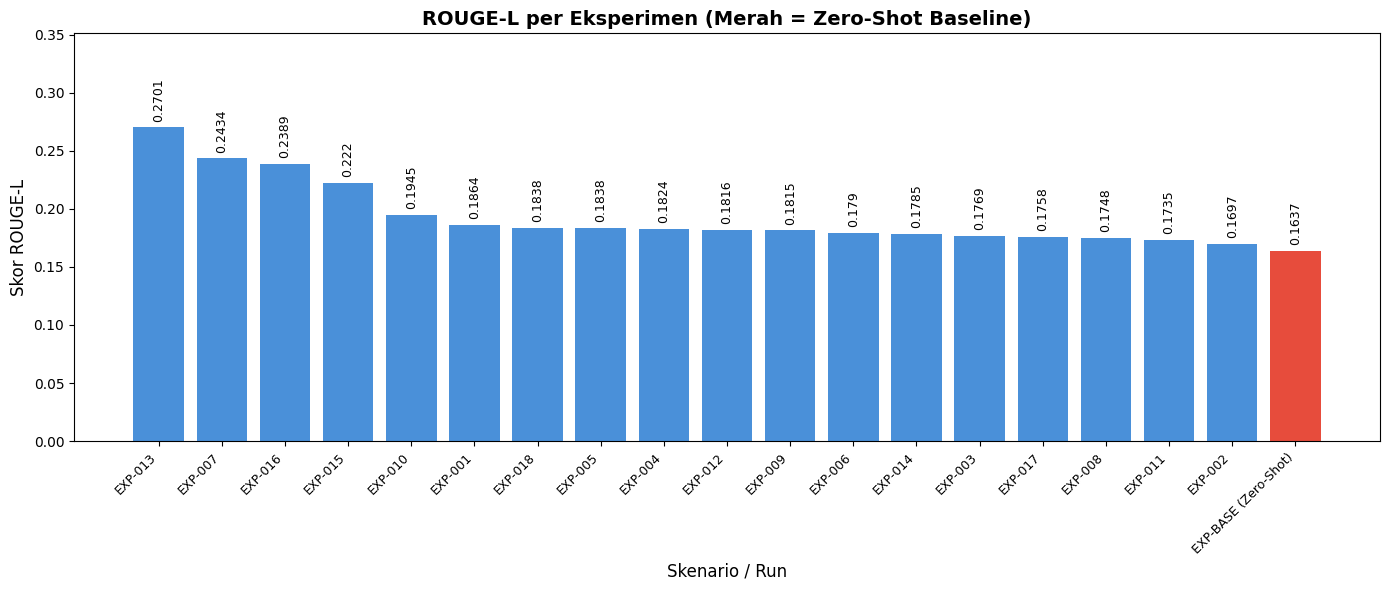

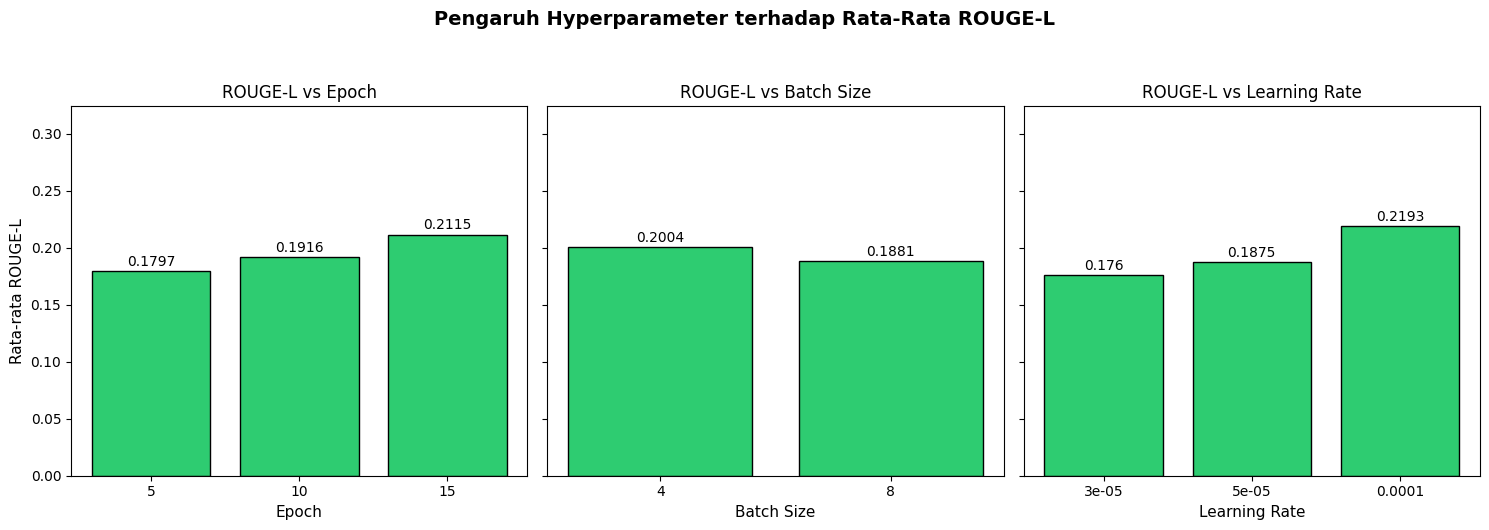

Grafik visualisasi sudah siap!


In [8]:
import matplotlib.pyplot as plt

df_hasil_sorted = df_hasil.sort_values('rougeL', ascending=False).reset_index(drop=True)

# Grafik 1: ROUGE-L per Run
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#E74C3C' if 'Zero-Shot' in str(r) else '#4A90D9' for r in df_hasil_sorted['run']]
bars = ax.bar(df_hasil_sorted['run'], df_hasil_sorted['rougeL'], color=colors)
ax.set_title('ROUGE-L per Eksperimen (Merah = Zero-Shot Baseline)', fontsize=14, fontweight='bold')
ax.set_xlabel('Skenario / Run', fontsize=12)
ax.set_ylabel('Skor ROUGE-L', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.005,
            round(yval, 4), ha='center', va='bottom', fontsize=9, rotation=90)
ax.set_ylim(0, max(df_hasil_sorted['rougeL']) * 1.3)
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'rouge_per_run.png', dpi=150, bbox_inches='tight')
plt.show()

# Grafik 2: Pengaruh Hyperparameter
df_grid = df_hasil[df_hasil['run'] != 'EXP-BASE (Zero-Shot)'].copy()
df_grid['epoch'] = df_grid['epoch'].astype(int)
df_grid['batch_size'] = df_grid['batch_size'].astype(int)

fig2, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig2.suptitle('Pengaruh Hyperparameter terhadap Rata-Rata ROUGE-L', fontsize=14, fontweight='bold', y=1.05)

for ax, col, label in zip(axes, ['epoch', 'batch_size', 'learning_rate'], ['Epoch', 'Batch Size', 'Learning Rate']):
    g = df_grid.groupby(col)['rougeL'].mean().reset_index()
    bars_hp = ax.bar(g[col].astype(str), g['rougeL'], color='#2ECC71', edgecolor='black')
    ax.set_title(f'ROUGE-L vs {label}', fontsize=12)
    ax.set_xlabel(label, fontsize=11)
    if ax == axes[0]:
        ax.set_ylabel('Rata-rata ROUGE-L', fontsize=11)
    for bar in bars_hp:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.002,
                round(yval, 4), ha='center', va='bottom', fontsize=10)
axes[0].set_ylim(0, max(df_grid['rougeL']) * 1.2)
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'visualisasi_hyperparameter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik visualisasi sudah siap!')

## 9. Evaluasi Final Model Terbaik

In [ ]:
from torch.utils.data import DataLoader

print("EVALUASI FINAL: MODEL TERBAIK SETELAH TUNING")
print(f"Memuat dari: {BEST_DIR}...")

model_juara     = AutoModelForSeq2SeqLM.from_pretrained(BEST_DIR).to(DEVICE)
tokenizer_juara = AutoTokenizer.from_pretrained(BEST_DIR)
model_juara.eval()

preds_final = []
refs_final  = df_test['target_summary_manual'].tolist()

eval_collator_final = DataCollatorForSeq2Seq(
    tokenizer_juara,
    model=None,
    padding=True,
)

test_ds.set_format('torch')
loader_final = DataLoader(test_ds, batch_size=4, collate_fn=eval_collator_final)

print("Sedang memproses evaluasi akhir...")
with torch.no_grad():
    for batch in loader_final:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        outputs = model_juara.generate(
            input_ids,
            attention_mask=attention_mask,
            max_new_tokens=100,
            no_repeat_ngram_size=3,
            num_beams=4,
            repetition_penalty=2.0,
            early_stopping=True,
        )
        decoded = tokenizer_juara.batch_decode(outputs, skip_special_tokens=True)
        preds_final.extend(decoded)

preds_final = [p.replace(PREFIX, '').strip() for p in preds_final]
pairs = [(p, r) for p, r in zip(preds_final, refs_final) if p.strip()]

if pairs:
    p_clean, r_clean = zip(*pairs)
    rouge_final = evaluate.load('rouge')
    scores_final = rouge_final.compute(
        predictions=list(p_clean),
        references=list(r_clean),
        use_stemmer=False
    )
    print("\n=======================================================")
    print("SKOR ROUGE FINAL MODEL TERBAIK")
    print("=======================================================")
    print(f"  ROUGE-1 : {round(scores_final['rouge1'], 4)}")
    print(f"  ROUGE-2 : {round(scores_final['rouge2'], 4)}")
    print(f"  ROUGE-L : {round(scores_final['rougeL'], 4)}")
    print("\nBANDINGKAN HASIL TEKS:")
    print(f"  [Ringkasan Manual Asli] : {r_clean[0][:200]}...")
    print(f"  [Prediksi Model IndoT5] : {p_clean[0][:200]}...")
else:
    print("Gagal menghitung ROUGE.")

del model_juara
torch.cuda.empty_cache()
gc.collect()

EVALUASI FINAL: MODEL TERBAIK SETELAH TUNING
Memuat dari: /content/drive/MyDrive/models/indot5_finetuned...


Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Sedang memproses evaluasi akhir...

SKOR ROUGE FINAL MODEL TERBAIK
  ROUGE-1 : 0.4167
  ROUGE-2 : 0.1978
  ROUGE-L : 0.2702

BANDINGKAN HASIL TEKS:
  [Ringkasan Manual Asli] : Rapat Paripurna DPR RI membahas laporan Komisi III tentang hasil uji kelayakan calon anggota Lembaga Perlindungan Saksi dan Korban masa jabatan 2024-2029. Pimpinan Komisi III, Dr. Habibur Rahman, meny...
  [Prediksi Model IndoT5] : DPR RI menyampaikan laporan dari Komisi 3 DPR RI atas hasil uji kelayakan terhadap calon anggota lembaga perlindungan saksi dan korban masa jabatan 20242025. Anggota DPR RI meminta untuk memberikan ke...


2324